# Multi-Dataset Speech Emotion Recognition (SAVEE + TESS + CREMA-D + RAVDESS)

This notebook builds a unified, balanced metadata table for four acted speech emotion datasets and prepares a speaker-based train/test split. It also includes an optional Wav2Vec2 training pipeline.

Target emotions: **happy**, **sad**, **angry**, **neutral**.

## 1. Imports and Global Settings

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    Trainer,
    TrainingArguments,
)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Matplotlib style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Define Dataset Paths

In [2]:
# Update these paths to your local dataset locations
BASE_DIR = Path(os.getcwd())

CREMA_PATH = Path(r"C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA")
RAVDESS_PATH = Path(r"C:\Users\LOQ\Desktop\testpi\DATASETS\RAVDESS")
TESS_PATH = Path(r"C:\Users\LOQ\Desktop\testpi\DATASETS\Tess")
SAVEE_PATH = Path(r"C:\Users\LOQ\Desktop\testpi\DATASETS\SAVEE")

## 3. Parse CREMA-D Filenames

In [3]:
CREMA_MAP = {
    "ANG": "angry",
    "HAP": "happy",
    "SAD": "sad",
    "NEU": "neutral",
}


def parse_crema_d(crema_path: Path) -> pd.DataFrame:
    if not crema_path.exists():
        print(f"[WARN] CREMA-D path not found: {crema_path}")
        return pd.DataFrame(columns=["file_path", "dataset_name", "speaker_id", "audio_id", "emotion"])

    rows = []
    wav_paths = list(crema_path.rglob("*.wav"))
    for wav_path in tqdm(wav_paths, desc="CREMA-D", unit="file"):
        parts = wav_path.stem.split("_")
        if len(parts) < 3:
            continue
        speaker_id = parts[0]
        emotion_code = parts[2]
        emotion = CREMA_MAP.get(emotion_code)
        if emotion is None:
            continue
        rows.append(
            {
                "file_path": str(wav_path),
                "dataset_name": "CREMA-D",
                "speaker_id": speaker_id,
                "audio_id": wav_path.stem,
                "emotion": emotion,
            }
        )

    return pd.DataFrame(rows)


df_crema = parse_crema_d(CREMA_PATH)
df_crema.head()

CREMA-D: 100%|██████████| 7442/7442 [00:00<00:00, 1050764.50file/s]


,file_path,dataset_name,speaker_id,audio_id,emotion
0,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_ANG_XX,angry
1,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_HAP_XX,happy
2,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_NEU_XX,neutral
3,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_SAD_XX,sad
4,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_IEO_ANG_HI,angry


## 4. Parse RAVDESS Filenames

In [4]:
RAVDESS_MAP = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
}


def parse_ravdess(ravdess_path: Path) -> pd.DataFrame:
    if not ravdess_path.exists():
        print(f"[WARN] RAVDESS path not found: {ravdess_path}")
        return pd.DataFrame(columns=["file_path", "dataset_name", "speaker_id", "audio_id", "emotion"])

    rows = []
    wav_paths = list(ravdess_path.rglob("*.wav"))
    for wav_path in tqdm(wav_paths, desc="RAVDESS", unit="file"):
        # Example: 03-01-05-01-01-01-12.wav
        parts = wav_path.stem.split("-")
        if len(parts) < 7:
            continue
        emotion_code = parts[2]
        emotion = RAVDESS_MAP.get(emotion_code)
        if emotion is None:
            continue
        speaker_id = parts[-1]
        rows.append(
            {
                "file_path": str(wav_path),
                "dataset_name": "RAVDESS",
                "speaker_id": speaker_id,
                "audio_id": wav_path.stem,
                "emotion": emotion,
            }
        )

    return pd.DataFrame(rows)


df_ravdess = parse_ravdess(RAVDESS_PATH)
df_ravdess.head()

RAVDESS: 100%|██████████| 1440/1440 [00:00<?, ?file/s]


,file_path,dataset_name,speaker_id,audio_id,emotion
0,C:\Users\LOQ\Desktop\testpi\DATASETS\RAVDESS\A...,RAVDESS,01,03-01-01-01-01-01-01,neutral
1,C:\Users\LOQ\Desktop\testpi\DATASETS\RAVDESS\A...,RAVDESS,01,03-01-01-01-01-02-01,neutral
2,C:\Users\LOQ\Desktop\testpi\DATASETS\RAVDESS\A...,RAVDESS,01,03-01-01-01-02-01-01,neutral
3,C:\Users\LOQ\Desktop\testpi\DATASETS\RAVDESS\A...,RAVDESS,01,03-01-01-01-02-02-01,neutral
4,C:\Users\LOQ\Desktop\testpi\DATASETS\RAVDESS\A...,RAVDESS,01,03-01-03-01-01-01-01,happy


## 5. Parse TESS Filenames

In [5]:
TESS_KEYWORDS = ["angry", "happy", "sad", "neutral"]


def parse_tess(tess_path: Path) -> pd.DataFrame:
    if not tess_path.exists():
        print(f"[WARN] TESS path not found: {tess_path}")
        return pd.DataFrame(columns=["file_path", "dataset_name", "speaker_id", "audio_id", "emotion"])

    rows = []
    wav_paths = list(tess_path.rglob("*.wav"))
    for wav_path in tqdm(wav_paths, desc="TESS", unit="file"):
        lower_name = wav_path.name.lower()
        emotion = None
        for kw in TESS_KEYWORDS:
            if kw in lower_name or kw in str(wav_path.parent).lower():
                emotion = kw
                break
        if emotion is None:
            continue

        # Speaker prefix like OAF or YAF if present
        speaker_id = "unknown"
        stem_parts = wav_path.stem.split("_")
        if len(stem_parts) > 0 and stem_parts[0] in {"OAF", "YAF"}:
            speaker_id = stem_parts[0]

        rows.append(
            {
                "file_path": str(wav_path),
                "dataset_name": "TESS",
                "speaker_id": speaker_id,
                "audio_id": wav_path.stem,
                "emotion": emotion,
            }
        )

    return pd.DataFrame(rows)


df_tess = parse_tess(TESS_PATH)
df_tess.head()

TESS: 100%|██████████| 2800/2800 [00:00<00:00, 183741.96file/s]


,file_path,dataset_name,speaker_id,audio_id,emotion
0,C:\Users\LOQ\Desktop\testpi\DATASETS\Tess\OAF_...,TESS,OAF,OAF_back_angry,angry
1,C:\Users\LOQ\Desktop\testpi\DATASETS\Tess\OAF_...,TESS,OAF,OAF_back_happy,happy
2,C:\Users\LOQ\Desktop\testpi\DATASETS\Tess\OAF_...,TESS,OAF,OAF_back_neutral,neutral
3,C:\Users\LOQ\Desktop\testpi\DATASETS\Tess\OAF_...,TESS,OAF,OAF_back_sad,sad
4,C:\Users\LOQ\Desktop\testpi\DATASETS\Tess\OAF_...,TESS,OAF,OAF_bar_angry,angry


## 6. Parse SAVEE Filenames

In [6]:
SAVEE_MAP = {
    "a": "angry",
    "h": "happy",
    "sa": "sad",
    "n": "neutral",
}


def parse_savee(savee_path: Path) -> pd.DataFrame:
    if not savee_path.exists():
        print(f"[WARN] SAVEE path not found: {savee_path}")
        return pd.DataFrame(columns=["file_path", "dataset_name", "speaker_id", "audio_id", "emotion"])

    rows = []
    wav_paths = list(savee_path.rglob("*.wav"))
    for wav_path in tqdm(wav_paths, desc="SAVEE", unit="file"):
        # Example: DC_a01.wav or DC_sa01.wav
        stem = wav_path.stem
        if "_" not in stem:
            continue
        speaker_id, code_part = stem.split("_", 1)
        emotion_code = "sa" if code_part.startswith("sa") else code_part[0]
        emotion = SAVEE_MAP.get(emotion_code)
        if emotion is None:
            continue

        rows.append(
            {
                "file_path": str(wav_path),
                "dataset_name": "SAVEE",
                "speaker_id": speaker_id,
                "audio_id": wav_path.stem,
                "emotion": emotion,
            }
        )

    return pd.DataFrame(rows)


df_savee = parse_savee(SAVEE_PATH)
df_savee.head()

SAVEE: 100%|██████████| 480/480 [00:00<?, ?file/s]


,file_path,dataset_name,speaker_id,audio_id,emotion
0,C:\Users\LOQ\Desktop\testpi\DATASETS\SAVEE\DC_...,SAVEE,DC,DC_a01,angry
1,C:\Users\LOQ\Desktop\testpi\DATASETS\SAVEE\DC_...,SAVEE,DC,DC_a02,angry
2,C:\Users\LOQ\Desktop\testpi\DATASETS\SAVEE\DC_...,SAVEE,DC,DC_a03,angry
3,C:\Users\LOQ\Desktop\testpi\DATASETS\SAVEE\DC_...,SAVEE,DC,DC_a04,angry
4,C:\Users\LOQ\Desktop\testpi\DATASETS\SAVEE\DC_...,SAVEE,DC,DC_a05,angry


## 7. Build Unified Metadata DataFrame

In [7]:
TARGET_EMOTIONS = ["happy", "sad", "angry", "neutral"]


df_all = pd.concat([df_crema, df_ravdess, df_tess, df_savee], ignore_index=True)
df_all = df_all[df_all["emotion"].isin(TARGET_EMOTIONS)].reset_index(drop=True)

print(f"Total samples: {len(df_all):,}")
df_all.head()

Total samples: 7,472


,file_path,dataset_name,speaker_id,audio_id,emotion
0,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_ANG_XX,angry
1,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_HAP_XX,happy
2,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_NEU_XX,neutral
3,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_DFA_SAD_XX,sad
4,C:\Users\LOQ\Desktop\testpi\DATASETS\CREMA\100...,CREMA-D,1001,1001_IEO_ANG_HI,angry


## 8. Dataset Summary Tables

In [8]:
print("Samples per dataset:")
print(df_all["dataset_name"].value_counts(), end="\n\n")

print("Samples per emotion:")
print(df_all["emotion"].value_counts(), end="\n\n")

print("Emotion x Dataset crosstab:")
print(pd.crosstab(df_all["emotion"], df_all["dataset_name"]))

Samples per dataset:
dataset_name
CREMA-D    4900
TESS       1600
RAVDESS     672
SAVEE       300
Name: count, dtype: int64

Samples per emotion:
emotion
angry      1923
happy      1923
sad        1923
neutral    1703
Name: count, dtype: int64

Emotion x Dataset crosstab:
dataset_name  CREMA-D  RAVDESS  SAVEE  TESS
emotion                                    
angry            1271      192     60   400
happy            1271      192     60   400
neutral          1087       96    120   400
sad              1271      192     60   400


## 9. Emotion Balancing Strategy

In [9]:
MAX_PER_CLASS = None  # Set to an int to cap per-emotion samples


def balance_by_emotion(df: pd.DataFrame, max_per_class=None, random_state=RANDOM_STATE) -> pd.DataFrame:
    counts = df["emotion"].value_counts()
    if counts.empty:
        return df.copy()

    min_count = counts.min()
    samples_per_class = min_count if max_per_class is None else min(min_count, max_per_class)

    balanced = (
        df.groupby("emotion", group_keys=False)
        .apply(lambda x: x.sample(samples_per_class, random_state=random_state))
        .reset_index(drop=True)
    )

    return balanced


df_balanced = balance_by_emotion(df_all, MAX_PER_CLASS)
print(df_balanced["emotion"].value_counts())

emotion
angry      1703
happy      1703
neutral    1703
sad        1703
Name: count, dtype: int64


C:\Users\LOQ\AppData\Local\Temp\ipykernel_14856\3954476386.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(samples_per_class, random_state=random_state))


## 10. Optional Dataset-Aware Balancing

In [10]:
APPLY_DATASET_AWARE_BALANCE = True


def dataset_aware_balance(
    df: pd.DataFrame,
    target_per_emotion: int,
    random_state=RANDOM_STATE,
) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    rng = np.random.RandomState(random_state)
    balanced_rows = []

    for emotion in df["emotion"].unique():
        df_e = df[df["emotion"] == emotion]
        datasets = df_e["dataset_name"].unique()
        if len(datasets) == 0:
            continue

        per_dataset_cap = max(1, int(target_per_emotion / len(datasets)))
        selected = []

        # First pass: per-dataset cap
        for ds in datasets:
            df_ds = df_e[df_e["dataset_name"] == ds]
            take = min(len(df_ds), per_dataset_cap)
            if take > 0:
                selected.append(df_ds.sample(take, random_state=rng.randint(0, 1_000_000)))

        selected_df = pd.concat(selected) if selected else pd.DataFrame()

        # Second pass: fill remaining from any dataset
        remaining = target_per_emotion - len(selected_df)
        if remaining > 0:
            leftover = df_e.drop(selected_df.index, errors="ignore")
            if len(leftover) > 0:
                extra = leftover.sample(min(remaining, len(leftover)), random_state=rng.randint(0, 1_000_000))
                selected_df = pd.concat([selected_df, extra])

        balanced_rows.append(selected_df)

    return pd.concat(balanced_rows, ignore_index=True) if balanced_rows else df.copy()


if APPLY_DATASET_AWARE_BALANCE and not df_balanced.empty:
    target = df_balanced["emotion"].value_counts().min()
    df_balanced = dataset_aware_balance(df_balanced, target)

print(df_balanced["dataset_name"].value_counts())

dataset_name
CREMA-D    4459
TESS       1456
RAVDESS     609
SAVEE       288
Name: count, dtype: int64


## 11. Speaker-Based Train/Test Split

In [11]:
if not df_balanced.empty:
    df_balanced = df_balanced.copy()
    df_balanced["unique_speaker_id"] = df_balanced["dataset_name"] + "_" + df_balanced["speaker_id"].astype(str)

    unique_speakers = df_balanced["unique_speaker_id"].unique()
    train_speakers, test_speakers = train_test_split(
        unique_speakers,
        test_size=0.2,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    df_balanced["split"] = np.where(
        df_balanced["unique_speaker_id"].isin(train_speakers), "train", "test"
    )

    print(df_balanced["split"].value_counts())
else:
    print("[WARN] No data available for splitting.")

split
train    5626
test     1186
Name: count, dtype: int64


## 12. Distribution Visualizations

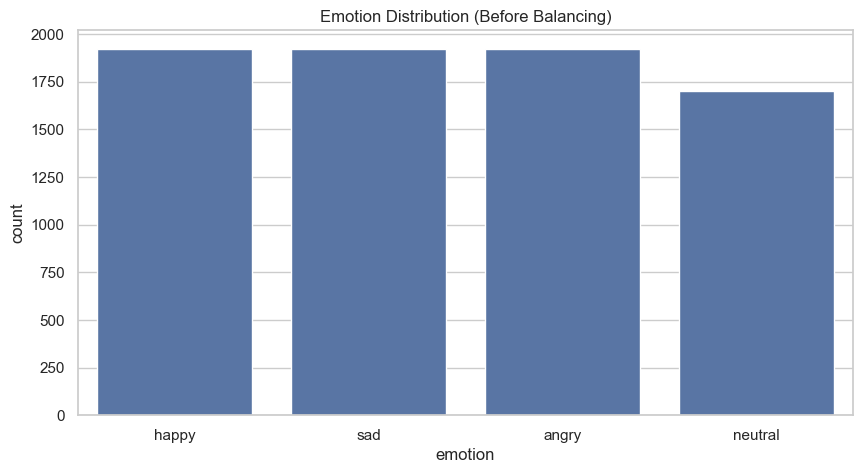

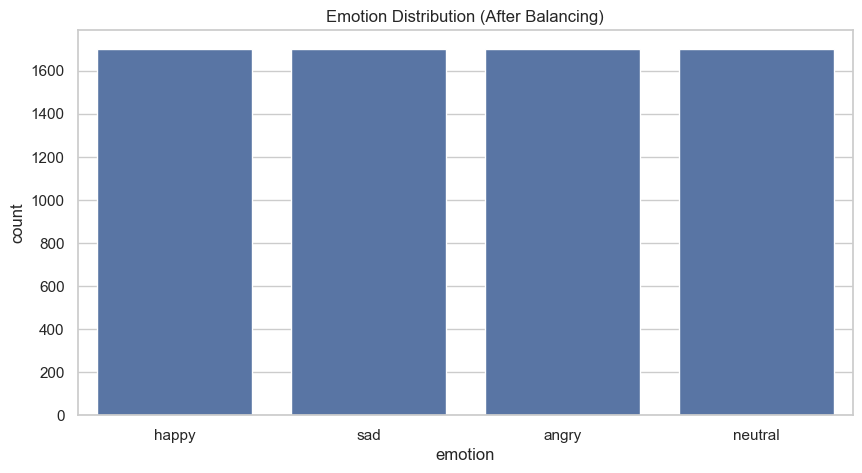

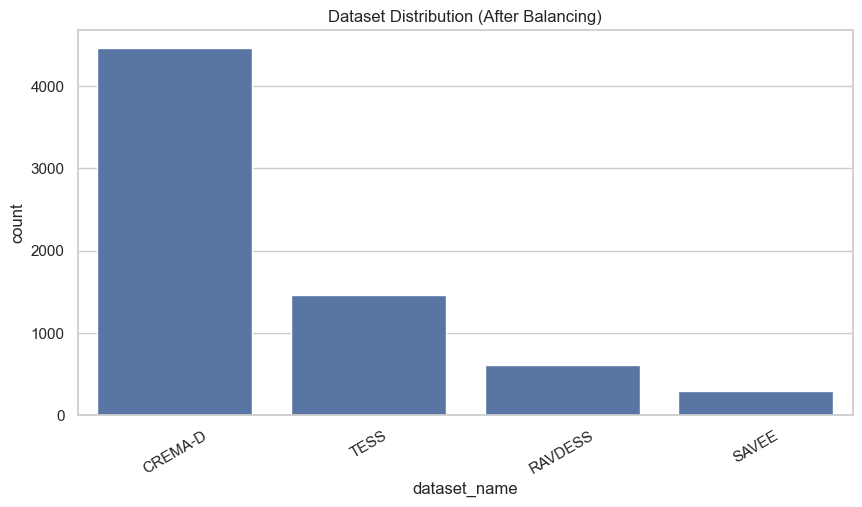

In [12]:
if not df_all.empty:
    plt.figure()
    sns.countplot(data=df_all, x="emotion", order=TARGET_EMOTIONS)
    plt.title("Emotion Distribution (Before Balancing)")
    plt.show()

if not df_balanced.empty:
    plt.figure()
    sns.countplot(data=df_balanced, x="emotion", order=TARGET_EMOTIONS)
    plt.title("Emotion Distribution (After Balancing)")
    plt.show()

    plt.figure()
    sns.countplot(data=df_balanced, x="dataset_name")
    plt.title("Dataset Distribution (After Balancing)")
    plt.xticks(rotation=30)
    plt.show()

## 13. Save Metadata Outputs

In [13]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

metadata_path = output_dir / "multidataset_emotion_metadata.csv"
balanced_path = output_dir / "multidataset_emotion_balanced.csv"

df_all.to_csv(metadata_path, index=False)
df_balanced.to_csv(balanced_path, index=False)

print(f"Saved: {metadata_path}")
print(f"Saved: {balanced_path}")

Saved: outputs\multidataset_emotion_metadata.csv
Saved: outputs\multidataset_emotion_balanced.csv


## 14. Prepare Features for Wav2Vec2

In [14]:
PREPARE_FEATURES = True
MAX_DURATION_SEC = 5
TARGET_SR = 16000

LABELS = ["happy", "sad", "angry", "neutral"]
label2id = {label: idx for idx, label in enumerate(LABELS)}
id2label = {idx: label for label, idx in label2id.items()}


def load_audio_fixed_length(path: str, target_sr=TARGET_SR, max_duration_sec=MAX_DURATION_SEC):
    audio, sr = librosa.load(path, sr=target_sr, mono=True)
    max_len = int(target_sr * max_duration_sec)
    if len(audio) > max_len:
        audio = audio[:max_len]
    elif len(audio) < max_len:
        pad_width = max_len - len(audio)
        audio = np.pad(audio, (0, pad_width), mode="constant")
    return audio


class EmotionAudioDataset(Dataset):
    def __init__(self, df: pd.DataFrame, processor: Wav2Vec2Processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio = load_audio_fixed_length(row["file_path"])
        inputs = self.processor(audio, sampling_rate=TARGET_SR, return_tensors="pt")
        item = {"input_values": inputs.input_values.squeeze(0)}
        item["labels"] = torch.tensor(label2id[row["emotion"]], dtype=torch.long)
        return item


if PREPARE_FEATURES and not df_balanced.empty:
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

    df_train = df_balanced[df_balanced["split"] == "train"]
    df_test = df_balanced[df_balanced["split"] == "test"]

    train_dataset = EmotionAudioDataset(df_train, processor)
    test_dataset = EmotionAudioDataset(df_test, processor)

    print(len(train_dataset), len(test_dataset))
else:
    print("[INFO] Set PREPARE_FEATURES=True to build datasets.")

5626 1186


c:\Users\LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


## 15. Train Wav2Vec2ForSequenceClassification

In [15]:
RUN_TRAINING = True

if RUN_TRAINING and PREPARE_FEATURES:
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Class weights for imbalance handling
    class_counts = df_balanced[df_balanced["split"] == "train"]["emotion"].value_counts()
    weights = torch.tensor([1.0 / class_counts[label] for label in LABELS], dtype=torch.float)
    weights = weights.to(device)

    model = Wav2Vec2ForSequenceClassification.from_pretrained(
        "facebook/wav2vec2-base",
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    ).to(device)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro"),
        }

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    training_args = TrainingArguments(
        output_dir="outputs/wav2vec2-emotion",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        num_train_epochs=3,
        learning_rate=2e-5,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=processor,
        compute_metrics=compute_metrics,
    )

    trainer.train()
else:
    print("[INFO] Set RUN_TRAINING=True after PREPARE_FEATURES to train the model.")

c:\Users\LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\training_args.

  0%|          | 0/4221 [00:00<?, ?it/s]

{'loss': 1.0225, 'grad_norm': 9.25394344329834, 'learning_rate': 1.7673537076522153e-05, 'epoch': 0.36}
{'loss': 0.7646, 'grad_norm': 0.7343286275863647, 'learning_rate': 1.531390665719024e-05, 'epoch': 0.71}


  0%|          | 0/297 [00:00<?, ?it/s]

{'eval_loss': 1.0559642314910889, 'eval_accuracy': 0.7175379426644182, 'eval_macro_f1': 0.7178246427569257, 'eval_runtime': 15.3001, 'eval_samples_per_second': 77.516, 'eval_steps_per_second': 19.412, 'epoch': 1.0}
{'loss': 0.6665, 'grad_norm': 21.926908493041992, 'learning_rate': 1.2944799810471454e-05, 'epoch': 1.07}
{'loss': 0.5054, 'grad_norm': 1.223505973815918, 'learning_rate': 1.0580431177446104e-05, 'epoch': 1.42}
{'loss': 0.5042, 'grad_norm': 0.26411208510398865, 'learning_rate': 8.216062544420754e-06, 'epoch': 1.78}


  0%|          | 0/297 [00:00<?, ?it/s]

{'eval_loss': 0.7726725339889526, 'eval_accuracy': 0.8170320404721754, 'eval_macro_f1': 0.8156657488170664, 'eval_runtime': 10.6472, 'eval_samples_per_second': 111.391, 'eval_steps_per_second': 27.895, 'epoch': 2.0}
{'loss': 0.4343, 'grad_norm': 0.1116054356098175, 'learning_rate': 5.846955697701967e-06, 'epoch': 2.13}
{'loss': 0.343, 'grad_norm': 250.57577514648438, 'learning_rate': 3.47784885098318e-06, 'epoch': 2.49}
{'loss': 0.3152, 'grad_norm': 0.09416583180427551, 'learning_rate': 1.1087420042643924e-06, 'epoch': 2.84}


  0%|          | 0/297 [00:00<?, ?it/s]

{'eval_loss': 0.9646936655044556, 'eval_accuracy': 0.811973018549747, 'eval_macro_f1': 0.8116717968579978, 'eval_runtime': 10.734, 'eval_samples_per_second': 110.49, 'eval_steps_per_second': 27.669, 'epoch': 3.0}
{'train_runtime': 1029.5305, 'train_samples_per_second': 16.394, 'train_steps_per_second': 4.1, 'train_loss': 0.5578350021047802, 'epoch': 3.0}


## 16. Evaluate Metrics and Confusion Matrix

  0%|          | 0/297 [00:00<?, ?it/s]

Accuracy: 0.811973018549747
Macro F1: 0.8116717968579978
              precision    recall  f1-score   support

       happy       0.91      0.70      0.79       298
         sad       0.90      0.78      0.83       298
       angry       0.78      0.90      0.84       298
     neutral       0.72      0.87      0.79       292

    accuracy                           0.81      1186
   macro avg       0.83      0.81      0.81      1186
weighted avg       0.83      0.81      0.81      1186



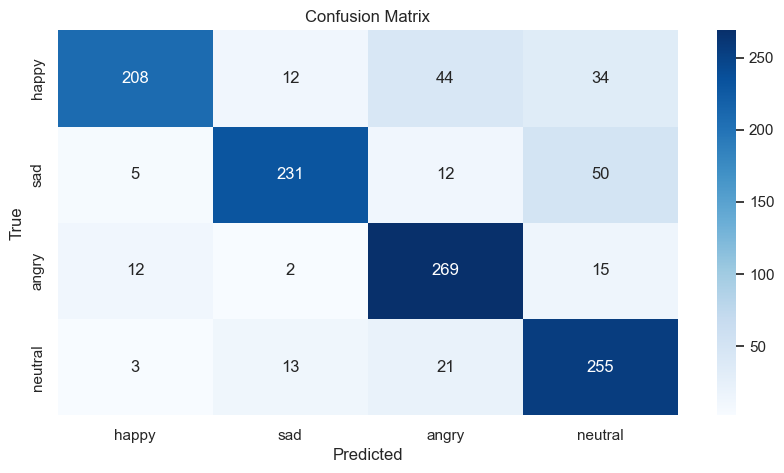

In [16]:
RUN_EVAL = True

if RUN_EVAL and RUN_TRAINING and PREPARE_FEATURES:
    preds_output = trainer.predict(test_dataset)
    preds = np.argmax(preds_output.predictions, axis=1)
    labels = preds_output.label_ids

    print("Accuracy:", accuracy_score(labels, preds))
    print("Macro F1:", f1_score(labels, preds, average="macro"))
    print(classification_report(labels, preds, target_names=LABELS))

    cm = confusion_matrix(labels, preds)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.show()
else:
    print("[INFO] Set RUN_EVAL=True after training to evaluate.")

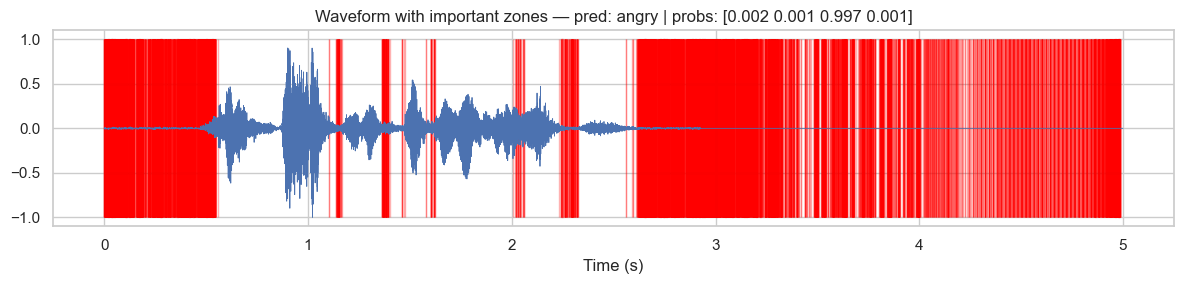

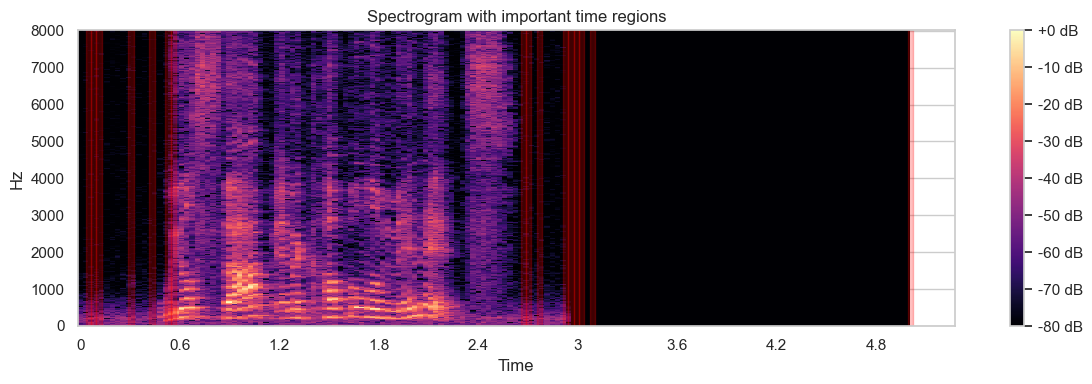

In [17]:
# XAI: waveform + important zones and spectrogram + important zones
try:
    assert "model" in globals() and "processor" in globals()
except Exception:
    print("[INFO] 'model' or 'processor' not found. Run PREPARE_FEATURES and training first.")
else:
    import librosa.display

    device = next(model.parameters()).device
    model.eval()

    if "df_test" not in globals() or len(df_test) == 0:
        print("[INFO] No test data available (df_test).")
    else:
        idx = 0
        file_path = df_test.iloc[idx]["file_path"]
        audio = load_audio_fixed_length(file_path)

        # Prepare input and enable gradients
        inputs = processor(audio, sampling_rate=TARGET_SR, return_tensors="pt")
        input_values = inputs.input_values.to(device)
        input_values.requires_grad_()

        outputs = model(input_values)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1).detach().cpu().numpy()[0]
        pred = int(torch.argmax(logits, dim=-1).cpu().numpy()[0])

        score = logits[0, pred]
        model.zero_grad()
        score.backward()

        grads = input_values.grad.detach().cpu().numpy()[0]
        saliency = np.abs(grads)
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

        times = np.linspace(0, len(audio) / TARGET_SR, num=len(audio))

        # Highlight top regions (top 10% by saliency)
        thr = np.percentile(saliency, 90)
        mask = saliency >= thr

        plt.figure(figsize=(12, 3))
        plt.plot(times, audio, color="C0", linewidth=0.6)
        plt.fill_between(times, -1.0, 1.0, where=mask, color="red", alpha=0.3)
        plt.title(f"Waveform with important zones — pred: {LABELS[pred]} | probs: {np.round(probs,3)}")
        plt.xlabel("Time (s)")
        plt.tight_layout()
        plt.show()

        # Spectrogram and aggregated saliency per frame
        n_fft = 1024
        hop_length = 512
        S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))
        S_db = librosa.amplitude_to_db(S, ref=np.max)
        n_frames = S.shape[1]

        frame_indices = np.floor(np.arange(len(saliency)) / hop_length).astype(int)
        frame_indices = np.clip(frame_indices, 0, n_frames - 1)
        frame_sal = np.zeros(n_frames)
        counts = np.zeros(n_frames)
        for i, fi in enumerate(frame_indices):
            frame_sal[fi] += saliency[i]
            counts[fi] += 1
        frame_sal = frame_sal / (counts + 1e-9)

        thr_f = np.percentile(frame_sal, 90)
        times_frames = librosa.frames_to_time(np.arange(n_frames), sr=TARGET_SR, hop_length=hop_length, n_fft=n_fft)

        plt.figure(figsize=(12, 4))
        librosa.display.specshow(S_db, sr=TARGET_SR, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma')
        for i, v in enumerate(frame_sal):
            if v >= thr_f:
                start = times_frames[i]
                end = start + hop_length / TARGET_SR
                plt.axvspan(start, end, color='red', alpha=0.25)
        plt.title('Spectrogram with important time regions')
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.show()

## 17. Warnings and Caveats

- These datasets contain **acted emotional speech**, not clinical bipolar disorder data.
- Emotion labels reflect **expressed affect**, not psychiatric diagnoses.
- Combining datasets improves diversity but can introduce **dataset-specific biases**.
- Speaker-based splitting reduces leakage, but **recording conditions** may still vary across datasets.